In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

analysis_data = pd.read_csv("f1_analysis_data_fixed.csv")
analysis_data

,Unnamed: 0.1,Unnamed: 0,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,...,IsAccurate,Year,Round,Session,fuel_kg,fuel_adjustment,fuel_effect,lap_time_s,fuel_delta_to_55,lap_time_fuel_std_55kg
0,1,1,0 days 01:05:53.220000,VER,1,0 days 00:01:37.880000,2.0,1.0,NaN,NaN,...,True,2022,1,Race,108.049107,3.241473,0.03,97.880,1.591473,96.288527
1,2,2,0 days 01:07:31.577000,VER,1,0 days 00:01:38.357000,3.0,1.0,NaN,NaN,...,True,2022,1,Race,106.098214,3.182946,0.03,98.357,1.532946,96.824054
2,3,3,0 days 01:09:10.143000,VER,1,0 days 00:01:38.566000,4.0,1.0,NaN,NaN,...,True,2022,1,Race,104.147321,3.124420,0.03,98.566,1.474420,97.091580
3,4,4,0 days 01:10:49.020000,VER,1,0 days 00:01:38.877000,5.0,1.0,NaN,NaN,...,True,2022,1,Race,102.196429,3.065893,0.03,98.877,1.415893,97.461107
4,5,5,0 days 01:12:27.960000,VER,1,0 days 00:01:38.940000,6.0,1.0,NaN,NaN,...,True,2022,1,Race,100.245536,3.007366,0.03,98.940,1.357366,97.582634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91975,103416,103416,0 days 02:13:00.598000,PIA,81,0 days 00:01:34.588000,46.0,2.0,NaN,NaN,...,True,2025,22,Race,9.668367,0.193367,0.02,94.588,-0.906633,95.494633
91976,103417,103417,0 days 02:14:34.684000,PIA,81,0 days 00:01:34.086000,47.0,2.0,NaN,NaN,...,True,2025,22,Race,7.438776,0.148776,0.02,94.086,-0.951224,95.037224
91977,103418,103418,0 days 02:16:08.849000,PIA,81,0 days 00:01:34.165000,48.0,2.0,NaN,NaN,...,True,2025,22,Race,5.209184,0.104184,0.02,94.165,-0.995816,95.160816
91978,103419,103419,0 days 02:17:43.315000,PIA,81,0 days 00:01:34.466000,49.0,2.0,NaN,NaN,...,True,2025,22,Race,2.979592,0.059592,0.02,94.466,-1.040408,95.506408


In [2]:
analysis_data = analysis_data.sort_values(
    ["Year", "Round", "Driver", "Stint", "LapNumber"]
)

analysis_data["lap_in_stint"] = (
    analysis_data
    .groupby(["Year", "Round", "Driver", "Stint"])
    .cumcount() + 1
)

analysis_data

,Unnamed: 0.1,Unnamed: 0,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,...,Year,Round,Session,fuel_kg,fuel_adjustment,fuel_effect,lap_time_s,fuel_delta_to_55,lap_time_fuel_std_55kg,lap_in_stint
350,417,417,0 days 01:06:03.288000,ALB,23,0 days 00:01:40.548000,2.0,1.0,NaN,NaN,...,2022,1,Race,108.049107,3.241473,0.03,100.548,1.591473,98.956527,1.0
351,418,418,0 days 01:07:43.952000,ALB,23,0 days 00:01:40.664000,3.0,1.0,NaN,NaN,...,2022,1,Race,106.098214,3.182946,0.03,100.664,1.532946,99.131054,2.0
352,419,419,0 days 01:09:25.078000,ALB,23,0 days 00:01:41.126000,4.0,1.0,NaN,NaN,...,2022,1,Race,104.147321,3.124420,0.03,101.126,1.474420,99.651580,3.0
353,420,420,0 days 01:11:07.381000,ALB,23,0 days 00:01:42.303000,5.0,1.0,NaN,NaN,...,2022,1,Race,102.196429,3.065893,0.03,102.303,1.415893,100.887107,4.0
354,421,421,0 days 01:12:49.089000,ALB,23,0 days 00:01:41.708000,6.0,1.0,NaN,NaN,...,2022,1,Race,100.245536,3.007366,0.03,101.708,1.357366,100.350634,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91258,102580,102580,0 days 02:12:34.851000,VER,1,0 days 00:01:34.017000,46.0,2.0,NaN,NaN,...,2025,22,Race,9.668367,0.193367,0.02,94.017,-0.906633,94.923633,20.0
91259,102581,102581,0 days 02:14:08.746000,VER,1,0 days 00:01:33.895000,47.0,2.0,NaN,NaN,...,2025,22,Race,7.438776,0.148776,0.02,93.895,-0.951224,94.846224,21.0
91260,102582,102582,0 days 02:15:42.868000,VER,1,0 days 00:01:34.122000,48.0,2.0,NaN,NaN,...,2025,22,Race,5.209184,0.104184,0.02,94.122,-0.995816,95.117816,22.0
91261,102583,102583,0 days 02:17:16.961000,VER,1,0 days 00:01:34.093000,49.0,2.0,NaN,NaN,...,2025,22,Race,2.979592,0.059592,0.02,94.093,-1.040408,95.133408,23.0


In [3]:
def compute_stint_tyre_deg(df,
                           time_col="lap_time_fuel_std_55kg",
                           lap_in_stint_col="lap_in_stint",
                           min_laps=3):

    results = []

    group_cols = ["Year", "Round", "Driver", "Stint"]

    for keys, g in df.groupby(group_cols):
        g = g.dropna(subset=[lap_in_stint_col, time_col])
        if len(g) < min_laps:
            continue

        x = g[lap_in_stint_col].astype(float).values
        y = g[time_col].astype(float).values

        slope, intercept = np.polyfit(x, y, 1)

        results.append({
            "Year":   keys[0],
            "Round":  keys[1],
            "Driver": keys[2],
            "Stint":  keys[3],
            "slope_s_per_lap": slope,
            "intercept_s":     intercept,
            "n_laps":          len(g),
        })

    return pd.DataFrame(results)

In [4]:
stint_deg = compute_stint_tyre_deg(analysis_data)
stint_deg

,Year,Round,Driver,Stint,slope_s_per_lap,intercept_s,n_laps
0,2022,1,ALB,1.0,0.292018,98.926236,11
1,2022,1,ALB,2.0,0.130616,99.241017,20
2,2022,1,ALB,3.0,0.094098,99.445009,7
3,2022,1,ALB,4.0,0.451848,98.217098,7
4,2022,1,ALO,1.0,0.298793,98.079000,9
...,...,...,...,...,...,...,...
4480,2025,22,SAI,2.0,-0.001470,95.606106,27
4481,2025,22,TSU,2.0,0.045961,96.331213,21
4482,2025,22,TSU,3.0,0.028005,95.826278,22
4483,2025,22,VER,1.0,-0.020392,95.937498,19


In [5]:
compound_per_stint = (
    analysis_data
    .groupby(["Year", "Round", "Driver", "Stint"])["Compound"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    .reset_index()
)

stint_deg = stint_deg.merge(
    compound_per_stint,
    on=["Year", "Round", "Driver", "Stint"],
    how="left"
)

team_per_stint = (
    analysis_data
    .groupby(["Year", "Round", "Driver", "Stint"])["Team"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    .reset_index()
)

stint_deg = stint_deg.merge(
    team_per_stint,
    on=["Year", "Round", "Driver", "Stint"],
    how="left"
)

stint_deg = stint_deg[
    ["Year", "Round", "Driver", "Team", "Stint",
     "Compound", "slope_s_per_lap", "intercept_s", "n_laps"]
]

stint_deg

,Year,Round,Driver,Team,Stint,Compound,slope_s_per_lap,intercept_s,n_laps
0,2022,1,ALB,Williams,1.0,C3,0.292018,98.926236,11
1,2022,1,ALB,Williams,2.0,C2,0.130616,99.241017,20
2,2022,1,ALB,Williams,3.0,C2,0.094098,99.445009,7
3,2022,1,ALB,Williams,4.0,C3,0.451848,98.217098,7
4,2022,1,ALO,Alpine,1.0,C3,0.298793,98.079000,9
...,...,...,...,...,...,...,...,...,...
4480,2025,22,SAI,Williams,2.0,C3,-0.001470,95.606106,27
4481,2025,22,TSU,Red Bull Racing,2.0,C3,0.045961,96.331213,21
4482,2025,22,TSU,Red Bull Racing,3.0,C4,0.028005,95.826278,22
4483,2025,22,VER,Red Bull Racing,1.0,C4,-0.020392,95.937498,19


In [6]:
# stint_deg.to_csv("stint_deg.csv")

In [7]:
laps_for_median = analysis_data.copy()

weekend_median = (
    laps_for_median
    .groupby(["Year", "Round"])["lap_time_fuel_std_55kg"]
    .median()
    .reset_index(name="track_median_laptime_s")
)

stint_deg = stint_deg.merge(
    weekend_median,
    on=["Year", "Round"],
    how="left"
)

stint_deg["deg_pct_per_lap"] = (
    stint_deg["slope_s_per_lap"] / stint_deg["track_median_laptime_s"] * 100
)

stint_deg

,Year,Round,Driver,Team,Stint,Compound,slope_s_per_lap,intercept_s,n_laps,track_median_laptime_s,deg_pct_per_lap
0,2022,1,ALB,Williams,1.0,C3,0.292018,98.926236,11,99.210804,0.294341
1,2022,1,ALB,Williams,2.0,C2,0.130616,99.241017,20,99.210804,0.131655
2,2022,1,ALB,Williams,3.0,C2,0.094098,99.445009,7,99.210804,0.094847
3,2022,1,ALB,Williams,4.0,C3,0.451848,98.217098,7,99.210804,0.455443
4,2022,1,ALO,Alpine,1.0,C3,0.298793,98.079000,9,99.210804,0.301170
...,...,...,...,...,...,...,...,...,...,...,...
4480,2025,22,SAI,Williams,2.0,C3,-0.001470,95.606106,27,96.138184,-0.001529
4481,2025,22,TSU,Red Bull Racing,2.0,C3,0.045961,96.331213,21,96.138184,0.047807
4482,2025,22,TSU,Red Bull Racing,3.0,C4,0.028005,95.826278,22,96.138184,0.029130
4483,2025,22,VER,Red Bull Racing,1.0,C4,-0.020392,95.937498,19,96.138184,-0.021211


In [8]:
schedule = pd.read_csv("f1_schedule_2018_2025.csv")

schedule = schedule.rename(
    columns={
        "year": "Year",
        "RoundNumber": "Round",
        "Location": "Track"
    }
)

schedule["Year"] = schedule["Year"].astype(int)
schedule["Round"] = schedule["Round"].astype(int)

# adding track to dataframes

stint_deg = stint_deg.merge(
    schedule[["Year", "Round", "Track"]],
    on=["Year", "Round"],
    how="left"
)

analysis_data = analysis_data.merge(
    schedule[["Year", "Round", "Track"]],
    on=["Year", "Round"],
    how="left"
)

# replacing old team names with current team names

team_map = {
    "RB": "Racing Bulls",
    "AlphaTauri": "Racing Bulls",
    "Racing Bulls": "Racing Bulls",
    "Alfa Romeo": "Kick Sauber",
    "Kick Sauber": "Kick Sauber",
}

track_map = {
    "Miami" : "Miami Gardens",
}

stint_deg["TeamUnified"] = stint_deg["Team"].replace(team_map)

stint_deg["TrackUnified"] = stint_deg["Track"].replace(track_map)

In [9]:
stint_deg

,Year,Round,Driver,Team,Stint,Compound,slope_s_per_lap,intercept_s,n_laps,track_median_laptime_s,deg_pct_per_lap,Track,TeamUnified,TrackUnified
0,2022,1,ALB,Williams,1.0,C3,0.292018,98.926236,11,99.210804,0.294341,Sakhir,Williams,Sakhir
1,2022,1,ALB,Williams,2.0,C2,0.130616,99.241017,20,99.210804,0.131655,Sakhir,Williams,Sakhir
2,2022,1,ALB,Williams,3.0,C2,0.094098,99.445009,7,99.210804,0.094847,Sakhir,Williams,Sakhir
3,2022,1,ALB,Williams,4.0,C3,0.451848,98.217098,7,99.210804,0.455443,Sakhir,Williams,Sakhir
4,2022,1,ALO,Alpine,1.0,C3,0.298793,98.079000,9,99.210804,0.301170,Sakhir,Alpine,Sakhir
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4480,2025,22,SAI,Williams,2.0,C3,-0.001470,95.606106,27,96.138184,-0.001529,Las Vegas,Williams,Las Vegas
4481,2025,22,TSU,Red Bull Racing,2.0,C3,0.045961,96.331213,21,96.138184,0.047807,Las Vegas,Red Bull Racing,Las Vegas
4482,2025,22,TSU,Red Bull Racing,3.0,C4,0.028005,95.826278,22,96.138184,0.029130,Las Vegas,Red Bull Racing,Las Vegas
4483,2025,22,VER,Red Bull Racing,1.0,C4,-0.020392,95.937498,19,96.138184,-0.021211,Las Vegas,Red Bull Racing,Las Vegas


In [10]:
slick_compounds = ["C1", "C2", "C3", "C4", "C5", "C6"]

metric = stint_deg["deg_pct_per_lap"]

mask_slick = stint_deg["Compound"].isin(slick_compounds)

stint_deg["deg_pct_per_lap_mixed"] = metric.where(
    ~mask_slick,
    metric.clip(lower=-0.03) # stints with greater negative slope tend to be outliers of shorter stints or strange conditions
)

avg_deg_per_compound = (
    stint_deg
    .groupby("Compound")["deg_pct_per_lap_mixed"]
    .mean()
    .reset_index(name="avg_deg_pct_per_lap")
    .sort_values("Compound", ascending=True)
)

avg_deg_per_compound

,Compound,avg_deg_pct_per_lap
0,C1,0.078236
1,C2,0.076904
2,C3,0.084841
3,C4,0.097012
4,C5,0.081358
5,C6,0.352052
6,I,-0.318923
7,W,-1.032324


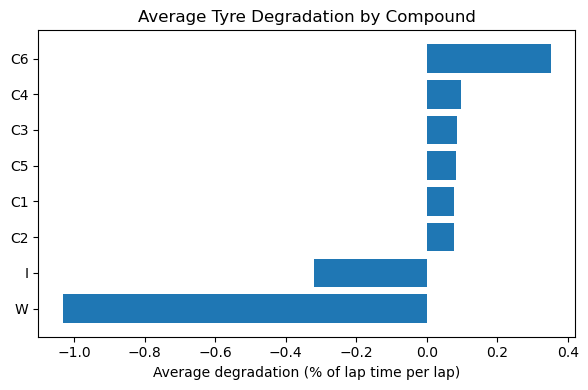

In [11]:
df = avg_deg_per_compound.sort_values("avg_deg_pct_per_lap", ascending=True)

plt.figure(figsize=(6, 4))
plt.barh(df["Compound"], df["avg_deg_pct_per_lap"])
plt.xlabel("Average degradation (% of lap time per lap)")
plt.title("Average Tyre Degradation by Compound")
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

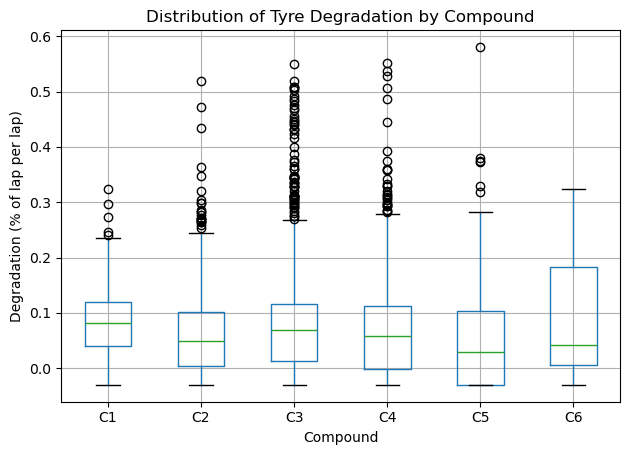

In [12]:
is_big_outlier_slick = mask_slick & (stint_deg["deg_pct_per_lap_mixed"] > 0.6)
stint_deg_filtered = stint_deg[~is_big_outlier_slick].copy()
stint_deg_dry_filtered = stint_deg_filtered[
    stint_deg_filtered["Compound"].isin(slick_compounds)
]

plt.figure(figsize=(6, 4))
stint_deg_dry_filtered.boxplot(column="deg_pct_per_lap_mixed", by="Compound")
plt.xlabel("Compound")
plt.ylabel("Degradation (% of lap per lap)")
plt.title("Distribution of Tyre Degradation by Compound")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [13]:
avg_deg_per_team = (
    stint_deg
    .groupby("TeamUnified")["deg_pct_per_lap_mixed"]
    .mean()
    .reset_index(name="avg_deg_pct_per_lap")
    .sort_values("avg_deg_pct_per_lap", ascending=False)
)

avg_deg_per_team

,TeamUnified,avg_deg_pct_per_lap
0,Alpine,0.080494
8,Red Bull Racing,0.075795
2,Ferrari,0.062314
9,Williams,0.056110
7,Racing Bulls,0.050302
5,McLaren,0.045502
4,Kick Sauber,0.044383
3,Haas F1 Team,0.044166
6,Mercedes,0.040739
1,Aston Martin,0.037079


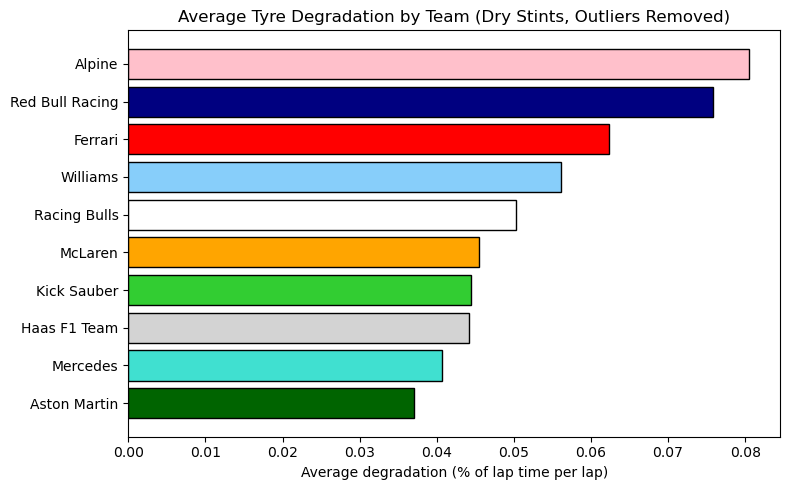

In [14]:
df = avg_deg_per_team.sort_values("avg_deg_pct_per_lap", ascending=False)

team_colors = {
    "Alpine":        "pink",
    "Red Bull Racing": "navy",
    "Ferrari":       "red",
    "Williams":      "lightskyblue",
    "Racing Bulls":  "white",
    "McLaren":       "orange",
    "Kick Sauber":   "limegreen",
    "Haas":          "maroon",
    "Mercedes":      "turquoise",
    "Aston Martin":  "darkgreen",
}

bar_colors = [
    team_colors.get(team, "lightgrey") 
    for team in df["TeamUnified"]
]

plt.figure(figsize=(8, 5))
plt.barh(
    df["TeamUnified"],
    df["avg_deg_pct_per_lap"],
    color=bar_colors,
    edgecolor="black"
)

plt.xlabel("Average degradation (% of lap time per lap)")
plt.title("Average Tyre Degradation by Team (Dry Stints, Outliers Removed)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
stint_deg_dry = stint_deg[stint_deg["Compound"].isin(slick_compounds)].copy()

avg_deg_per_track = (
    stint_deg_dry
    .groupby("TrackUnified")["deg_pct_per_lap_mixed"]
    .mean()
    .reset_index(name="avg_deg_pct_per_lap")
    .sort_values("avg_deg_pct_per_lap", ascending=False)
)

avg_deg_per_track

,TrackUnified,avg_deg_pct_per_lap
10,Melbourne,0.205769
16,Sakhir,0.147677
13,Monaco,0.142709
2,Barcelona,0.126610
18,Silverstone,0.112192
3,Budapest,0.110963
17,Shanghai,0.107655
20,Spielberg,0.104319
22,São Paulo,0.099699
19,Spa-Francorchamps,0.098734


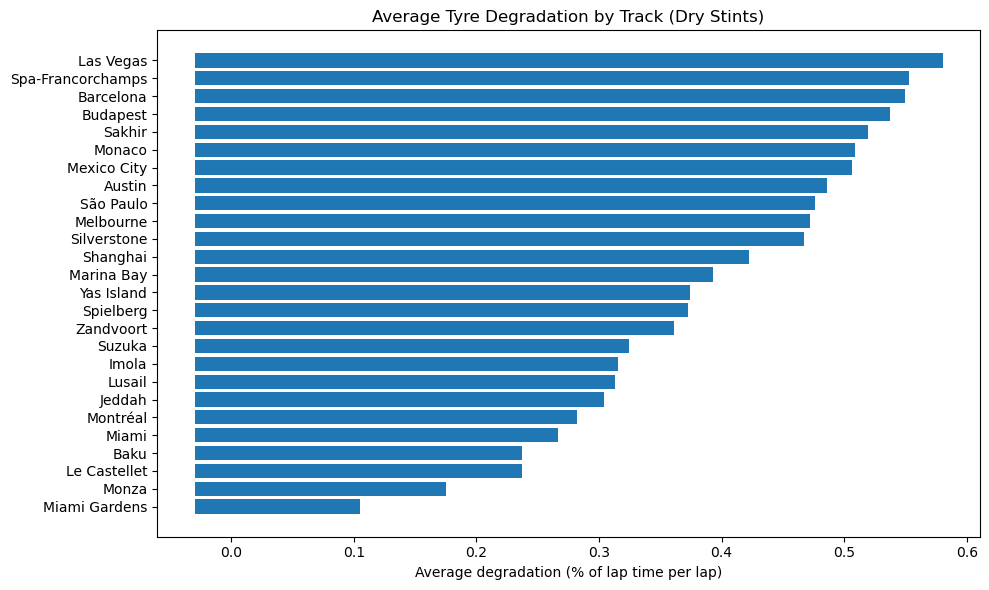

In [16]:
df_top = stint_deg_dry_filtered.sort_values("deg_pct_per_lap_mixed", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_top["Track"], df_top["deg_pct_per_lap_mixed"])
plt.xlabel("Average degradation (% of lap time per lap)")
plt.title("Average Tyre Degradation by Track (Dry Stints)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



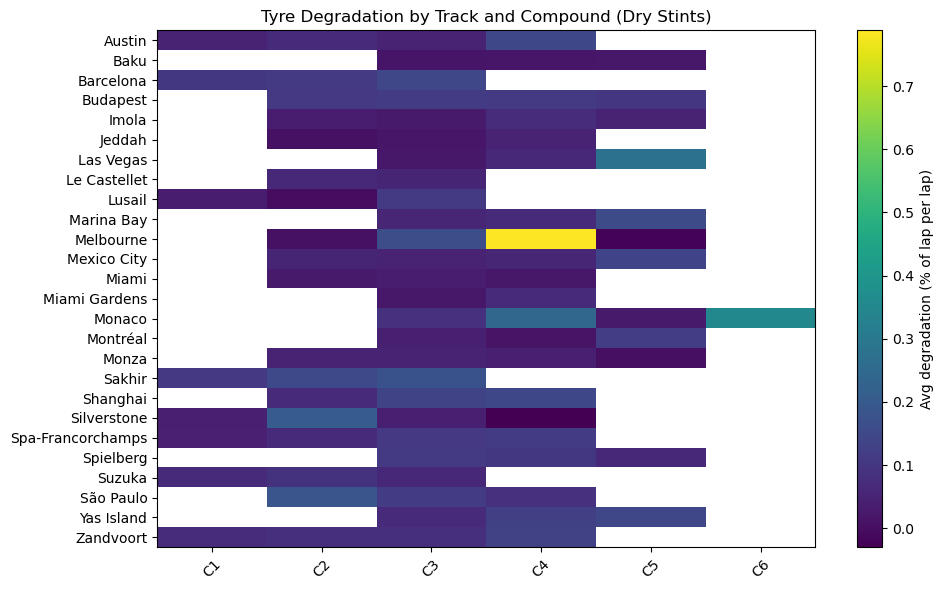

In [18]:
pivot = stint_deg_dry.pivot_table(
    index="Track",
    columns="Compound",
    values="deg_pct_per_lap_mixed",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Avg degradation (% of lap per lap)")
plt.xticks(ticks=range(len(pivot.columns)), labels=pivot.columns, rotation=45)
plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)
plt.title("Tyre Degradation by Track and Compound (Dry Stints)")
plt.tight_layout()
plt.show()

In [17]:
avg_deg_per_driver = (
    stint_deg_dry
    .groupby("Driver")["deg_pct_per_lap_mixed"]
    .mean()
    .reset_index(name="avg_deg_pct_per_lap")
    .sort_values("avg_deg_pct_per_lap", ascending=False)
)

avg_deg_per_driver

,Driver,avg_deg_pct_per_lap
14,LAW,0.155547
19,OCO,0.133162
9,GAS,0.124376
4,BOR,0.119165
13,LAT,0.103605
25,SAR,0.100825
27,TSU,0.100254
15,LEC,0.097797
8,DOO,0.094132
28,VER,0.093627
